In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("hamon_googlefit_medical_realistic.csv")
df.head()

,user_id,age,sex,bmi,smoking_status,family_history_cvd,fitness_level,height_m,weight_kg,date,...,body_temp_c,sleep_hours,sleep_efficiency,fatigue_score,calories_consumed,water_intake_l,sleep_data_available,bp_measured,glucose_measured,cardiometabolic_risk_state
0,1,23,1,30.753735,0,1,1,1.525007,71.532157,2024-01-01,...,36.7,7.58540,0.93389,4,2246,2.6,True,True,False,2
1,1,23,1,30.753735,0,1,1,1.525007,71.499318,2024-01-02,...,36.4,NaN,NaN,3,2497,2.3,False,False,False,2
2,1,23,1,30.753735,0,1,1,1.525007,71.507641,2024-01-03,...,36.7,7.01264,0.91370,5,2648,1.8,True,False,True,2
3,1,23,1,30.753735,0,1,1,1.525007,71.470106,2024-01-04,...,36.6,NaN,NaN,3,2923,2.1,False,False,True,2
4,1,23,1,30.753735,0,1,1,1.525007,71.475484,2024-01-05,...,36.3,NaN,NaN,4,2372,2.8,False,True,False,2


#### 1. Überblick
- Wie viele Tage Daten hast du?
- Durchschnittliche:
  - Schritte pro Tag
  - Kalorien
  - Distanz

Herausfinden, wie viele Tage vorhanden sind

In [3]:
days = df["date"].nunique() # zählt distinct Werte
days

30

In [4]:
days = df.groupby("date").size().count()
days

30

Nachforschen, ob wirklich alle User 30 Tage Daten haben.

In [5]:
# User finden, die keine 30 Tage Daten haben

df.groupby("user_id")["date"].nunique().loc[lambda x: x != 30]

Series([], Name: date, dtype: int64)

In [6]:
# Herausfinden, ob wirklich alle User 30 Tage haben
# True = Alle haben 30 Tage - False = mind. einer hat keine 30 Tage

(df.groupby("user_id")["date"].nunique() == 30).all()

True

- Herausfinden, wie viele Schritte jeder User im Mittel gemacht hat
- Herausfinden, wie viele Schritte alle User im Mittel gemacht haben

In [7]:
# Schritte pro Tag: 
df.groupby("user_id")["steps"].sum() / days

#BESSER, weil fehlerunanfälliger, wenn bspw. nicht jeder 30 Tage Daten hat
df.groupby("user_id")["steps"].mean()

user_id
1        7551.600000
2        9281.700000
3        3512.100000
4        5079.233333
5       10799.233333
            ...     
2996     8257.900000
2997     5338.800000
2998     8022.633333
2999     6900.166667
3000     6741.933333
Name: steps, Length: 3000, dtype: float64

In [8]:
df["steps"].mean()

6611.218988888889

In [9]:
df.groupby("user_id")["steps"].mean().mean()

6611.21898888889

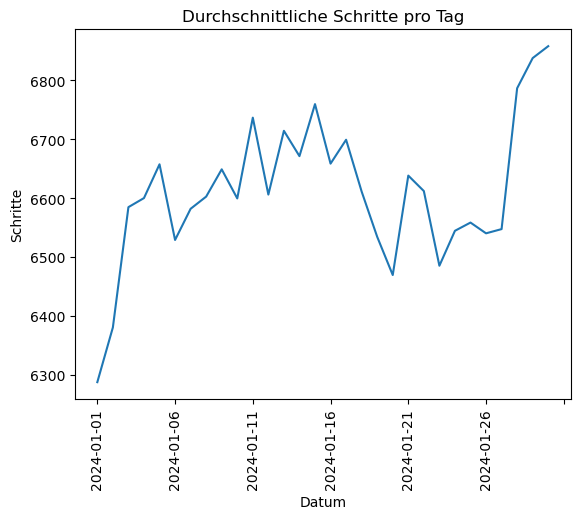

In [10]:
# Mittelwert je Tag
daily_avg = df.groupby("date")["steps"].mean()

daily_avg.plot()
plt.title("Durchschnittliche Schritte pro Tag")
plt.xlabel("Datum")
plt.ylabel("Schritte")
plt.xticks(rotation=90)
plt.show()

- Herausfinden, wie viele Kalorien verbrannt wurden, für jeden User und Mittelwert aller User

In [11]:
# Wert pro User
df.groupby("user_id")["calories_burned"].mean()

user_id
1       1934.600000
2       1980.966667
3       1748.200000
4       1789.233333
5       2049.566667
           ...     
2996    1946.266667
2997    1813.700000
2998    1951.600000
2999    1878.600000
3000    1866.100000
Name: calories_burned, Length: 3000, dtype: float64

In [12]:
# Mittelwert aller User
df.groupby("user_id")["calories_burned"].mean().mean()

1864.427611111111

- Herausfinden, wie viele Kalorien zugenommen wurden, für jeden User und Mittelwert aller User

In [13]:
# Wert pro User
df.groupby("user_id")["calories_consumed"].mean()

user_id
1       2495.266667
2       2392.466667
3       2460.733333
4       2444.733333
5       2540.900000
           ...     
2996    2404.633333
2997    2489.966667
2998    2557.433333
2999    2371.666667
3000    2425.600000
Name: calories_consumed, Length: 3000, dtype: float64

In [14]:
# Mittelwert aller User
df.groupby("user_id")["calories_consumed"].mean().mean()

2461.526977777778

- Herausfinden wie viele KM Distanz jeder User überwunden hat, pro User und insgesamt

In [15]:
# pro User
df.groupby("user_id")["distance_km"].mean()

user_id
1       5.663667
2       6.962333
3       2.634000
4       3.809333
5       8.099667
          ...   
2996    6.193667
2997    4.004000
2998    6.016667
2999    5.176000
3000    5.056333
Name: distance_km, Length: 3000, dtype: float64

In [16]:
# Mittelwert aller User
df.groupby("user_id")["distance_km"].mean().mean()

4.958455999999999

#### 2. Aktivster Tag
- An welchem Tag hattest du:
    - die meisten Schritte?
    - die meisten Kalorien?

- Herausfinden an welchem Tag jeder User die meisten Schritte getan hat

In [17]:
# gibt das Maximum an Schritten pro User aus
df.groupby("user_id")["steps"].max()

user_id
1       13472
2       14479
3        9311
4       11449
5       15084
        ...  
2996    15966
2997    11063
2998    12863
2999    13822
3000    12238
Name: steps, Length: 3000, dtype: int64

In [18]:
# gibt das Maximum an Schritten pro User aus, inklusive Datum des Tages
idx = df.groupby("user_id")["steps"].idxmax()

df.loc[idx, ["user_id", "date", "steps"]]

,user_id,date,steps
18,1,2024-01-19,13472
32,2,2024-01-03,14479
79,3,2024-01-20,9311
92,4,2024-01-03,11449
135,5,2024-01-16,15084
...,...,...,...
89864,2996,2024-01-15,15966
89903,2997,2024-01-24,11063
89921,2998,2024-01-12,12863
89946,2999,2024-01-07,13822


- Herausfinden an welchem Tag jeder User die meisten Kalorien verbrannt und was er an selbigen zu sich genommen hat

In [19]:
# sucht den max index aus der Spalte der konsumierten Kalorien
idx = df.groupby("user_id")["calories_consumed"].idxmax()

df.loc[idx, ["user_id", "date", "calories_consumed", "calories_burned"]]

,user_id,date,calories_consumed,calories_burned
24,1,2024-01-25,2978,1873
34,2,2024-01-05,3300,1888
79,3,2024-01-20,2952,1891
118,4,2024-01-29,3182,1669
139,5,2024-01-20,3077,2109
...,...,...,...,...
89859,2996,2024-01-10,2913,2144
89890,2997,2024-01-11,3139,1460
89925,2998,2024-01-16,3072,2113
89969,2999,2024-01-30,2781,1859


In [20]:
# sucht den max index aus der Spalte der konsumierten Kalorien
idx = df.groupby("user_id")["calories_burned"].idxmax()

df.loc[idx, ["user_id", "date", "calories_burned", "calories_consumed"]]

,user_id,date,calories_burned,calories_consumed
1,1,2024-01-02,2337,2497
36,2,2024-01-07,2371,2165
78,3,2024-01-19,2114,2779
92,4,2024-01-03,2192,2471
128,5,2024-01-09,2315,1859
...,...,...,...,...
89866,2996,2024-01-17,2351,2670
89903,2997,2024-01-24,2146,2484
89916,2998,2024-01-07,2238,2528
89953,2999,2024-01-14,2305,2216


#### 3. Wochentage vs Wochenende
- Vergleich:
    - Schritte (Mo–Fr vs Sa–So)


Insight: „Bin ich am Wochenende aktiver?“

In [21]:
# Datum in Wochentag umwandeln
df["date"] = pd.to_datetime(df["date"])

df["weekday"] = df["date"].dt.day_name()

In [22]:
# Wochenende vs. Wochentag in neuer Spalte teilen
df["is_weekend"] = df["date"].dt.weekday >= 5


In [23]:
# betrachtet alle User und gibt Mittelwert für Wochentage und Wochenende zurück
df.groupby("is_weekend")["steps"].mean()

is_weekend
False    6609.075364
True     6617.113958
Name: steps, dtype: float64

Insight: Wochentage und Wochenenden unterscheiden sich kaum in der Aktivität. Im Durchschnitt. 

In [24]:
# True = Wochenende
# False = Wochentag
df.groupby(["user_id", "is_weekend"])["steps"].mean().unstack()

is_weekend,False,True
user_id,,
1,7164.272727,8616.750
2,9536.590909,8580.750
3,3560.636364,3378.625
4,4831.818182,5759.625
5,11074.272727,10042.875
...,...,...
2996,8562.954545,7419.000
2997,4335.454545,8098.000
2998,7655.954545,9031.000


#### 4. Trendanalyse
- Entwickeln sich deine Schritte über die Zeit?
- Wirst du aktiver?

In [25]:
# Daten vorbereiten
df["date"] = pd.to_datetime(df["date"])

In [26]:
# Schritte pro Tag aggrigieren
daily_steps = df.groupby("date")["steps"].mean()

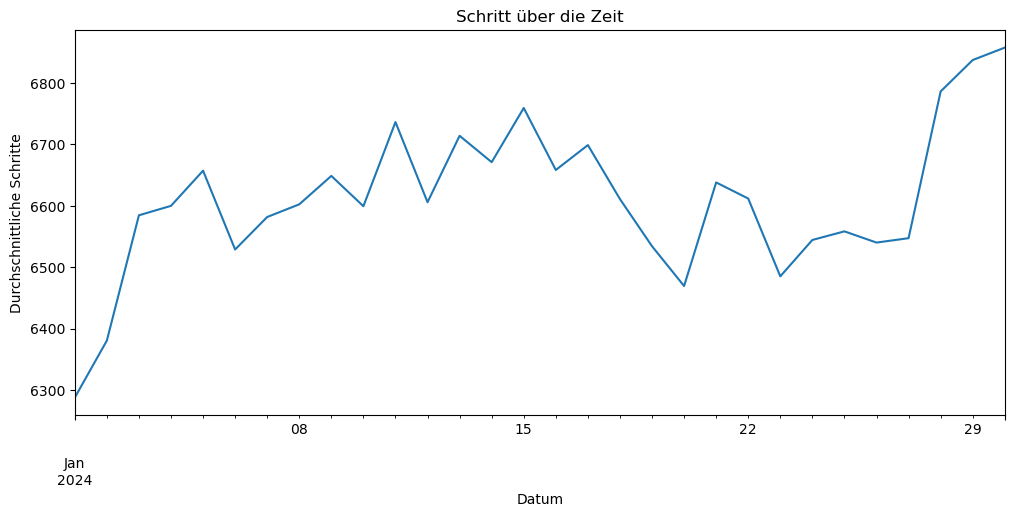

In [27]:
#trend plotten
daily_steps.plot(figsize=(12,5))
plt.title("Schritt über die Zeit")
plt.xlabel("Datum")
plt.ylabel("Durchschnittliche Schritte")

plt.show()

steigende Kurve zeigt einen Aufwärtstrend, sodass angenommen werden kann, dass die User über die Dauer hinweg eineSteigerung der gemachten Schritte pro Tag verbuchen.

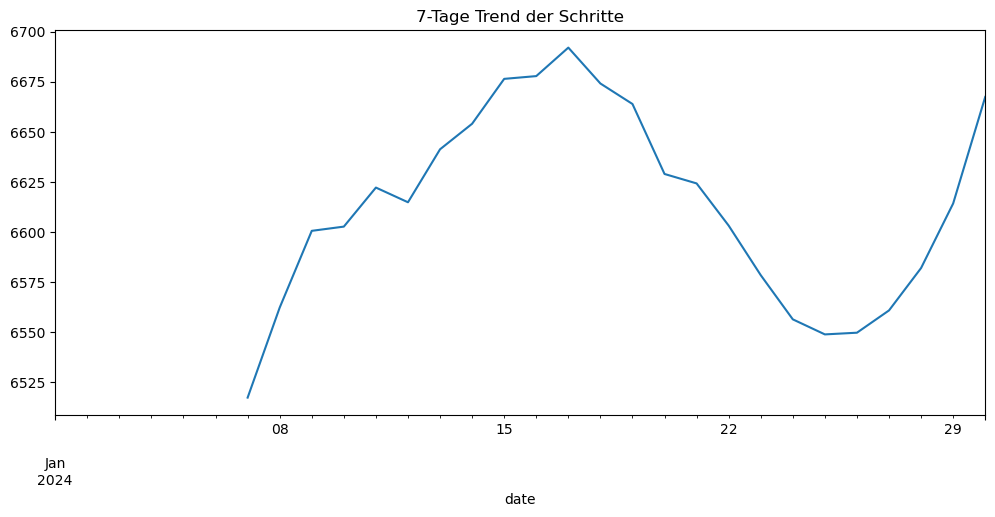

In [28]:
# trend glätten (entfernt Zufallsschwankung, zeigt en echten Trend)
daily_steps.rolling(window=7).mean().plot(figsize=(12,5))
plt.title("7-Tage Trend der Schritte")
plt.show()

In [29]:
#Trend berechnen
from scipy.stats import linregress

x = range(len(daily_steps))
y = daily_steps.values

slope, _ , _ , _, _ = linregress(x,y)
print(slope)
# > 0 -> man wird aktiver
# < 0 -> man wird weniger aktiv

5.547401928068223


Die User werden im Durchschnitt mit der Zeit aktiver.

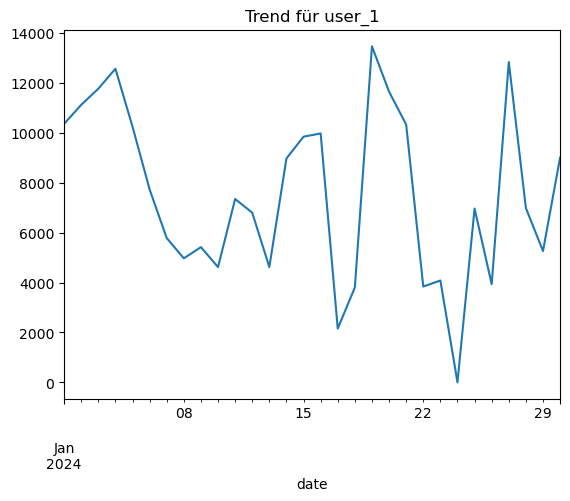

In [30]:
# für einzelne User betrachtet:

user_df = df[df["user_id"]== 1]

user_daily = user_df.groupby("date")["steps"].mean()
user_daily.plot()
plt.title("Trend für user_1")
plt.show()

In [31]:
def calc_trend(user_df):
    user_df = user_df.sort_values("date")
    x = range(len(user_df))
    y= user_df["steps"]
    
    slope, _,_,_,_ = linregress(x,y)
    return slope

trend_per_user = df.groupby("user_id").apply(calc_trend)
trend_per_user

user_id
1      -103.757063
2       -27.939266
3       114.531034
4      -221.710122
5       -43.115684
           ...    
2996    -73.849833
2997     69.289433
2998    -61.646941
2999     79.530367
3000     92.872525
Length: 3000, dtype: float64

#### 5. Korrelationen
- Zusammenhang zwischen:
    - Schritte ↔ Kalorien
    - Distanz ↔ Kalorien

Frage: „Verbrenne ich wirklich mehr, wenn ich mehr laufe?“

- ~ +1	starke positive Korrelation
- ~ 0	keine Korrelation
- ~ -1	starke negative Korrelation

In [32]:
corr_1 = df["steps"].corr(df["calories_burned"])
corr_1

0.7993972201909112

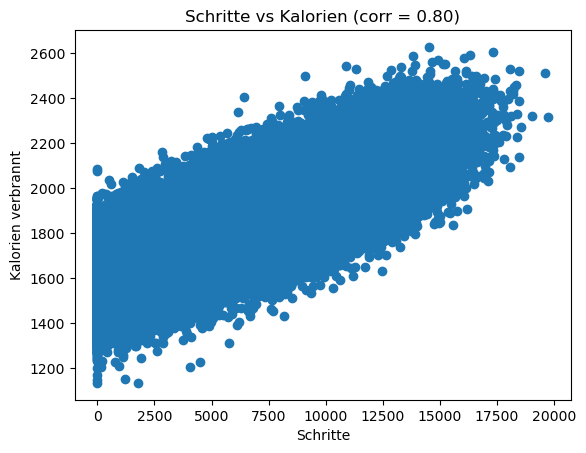

In [33]:
plt.scatter(df["steps"], df["calories_burned"])

plt.xlabel("Schritte")
plt.ylabel("Kalorien verbrannt")
plt.title(f"Schritte vs Kalorien (corr = {corr_1:.2f})")

plt.show()

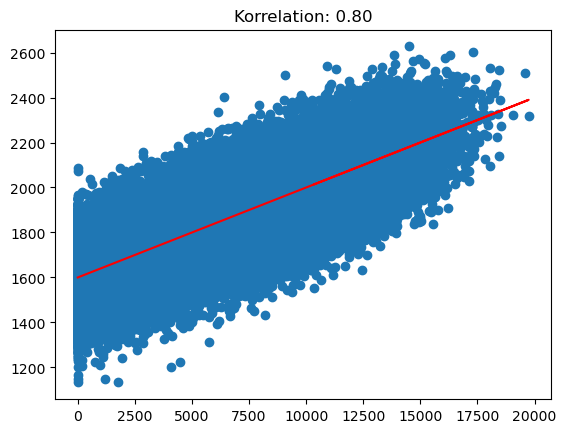

In [39]:
x_1 = df["steps"]
y_1 = df["calories_burned"]

plt.scatter(x_1, y_1)

# Trendlinie
m_1, b_1 = np.polyfit(x_1, y_1, 1)
plt.plot(x_1, m_1*x_1 + b_1, color="red")

plt.title(f"Korrelation: {df['steps'].corr(df['calories_burned']):.2f}")

plt.show()

In [35]:
corr_2 = df["distance_km"].corr(df["calories_burned"])
corr_2

0.7993962089314114

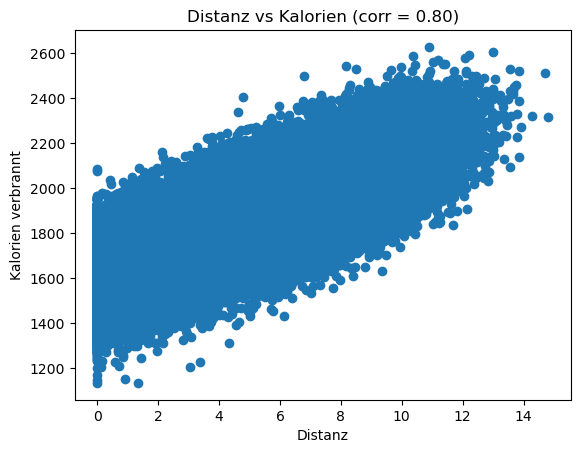

In [36]:
plt.scatter(df["distance_km"], df["calories_burned"])

plt.xlabel("Distanz")
plt.ylabel("Kalorien verbrannt")
plt.title(f"Distanz vs Kalorien (corr = {corr_2:.2f})")

plt.show()

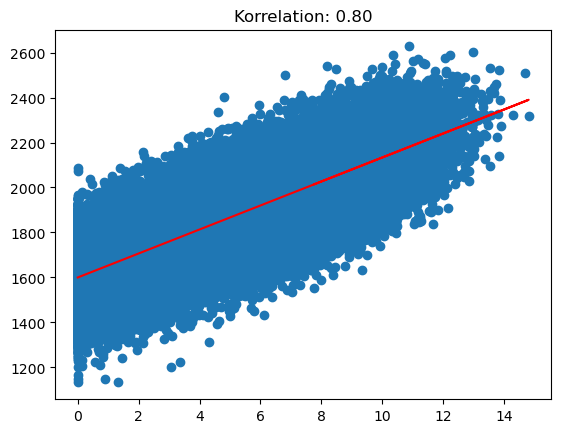

In [40]:

x_2 = df["distance_km"]
y_2 = df["calories_burned"]

plt.scatter(x_2, y_2)

# Trendlinie
m_2, b_2 = np.polyfit(x_2, y_2, 1)
plt.plot(x_2, m_2*x_2 + b_2, color="red")

plt.title(f"Korrelation: {df['distance_km'].corr(df['calories_burned']):.2f}")

plt.show()

Ich habe die Beziehung zwischen Schritten und Kalorien, sowie Distanz in km und Kalorien, sowohl visuell mittels Scatterplot als auch quantitativ mit dem Korrelationskoeffizienten analysiert.

- Welche Variable hat die höchste Korrelation mit Gesundheitsrisiko?

In [41]:
# nur nummerische Spalten wählen
numeric_df = df.select_dtypes(include="number")

In [43]:
# korrelation berechnen
corr = numeric_df.corr()["cardiometabolic_risk_state"].sort_values(ascending=False)
corr

cardiometabolic_risk_state    1.000000
fatigue_score                 0.819187
bp_systolic                   0.693444
bp_diastolic                  0.648303
resting_hr                    0.639983
fasting_glucose               0.632738
body_temp_c                   0.501656
postprandial_glucose          0.471947
avg_heart_rate                0.380531
bmi                           0.156224
age                           0.152594
smoking_status                0.121780
family_history_cvd            0.120103
weight_kg                     0.115404
day_index                     0.062833
calories_consumed             0.021284
sex                           0.007568
water_intake_l                0.000592
height_m                     -0.018817
user_id                      -0.022573
cycling_power_watts          -0.035775
spo2                         -0.124749
fitness_level                -0.311414
calories_burned              -0.363218
heart_points                 -0.414897
move_minutes             

- positiv → erhöht Risiko
- negativ → schützt

In [ ]:
# Anzeigen der besten Variable
corr.drop("cardiometabolic_risk_state").abs().idxmax()

'fatigue_score'

<Axes: >

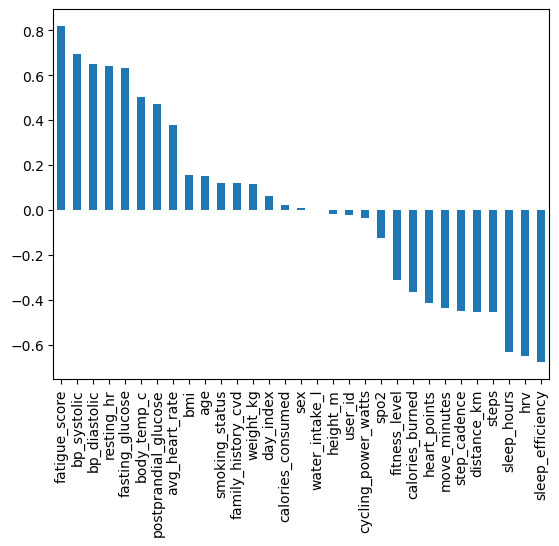

In [ ]:
# plot aller variablen
corr.drop("cardiometabolic_risk_state").plot(kind="bar")

- Wie unterscheiden sich High-Risk und Low Risk Nutzer konkret?

In [46]:
low_risk = df[df["cardiometabolic_risk_state"] == 0]
high_risk = df[df["cardiometabolic_risk_state"] == 4]

In [ ]:
# Durchschnittswerte vergleichen (steps, bmi, resting_hr. sleep_hours, calories_burned)
comparison = df.groupby("cardiometabolic_risk_state").mean(numeric_only=True)
comparison

,user_id,age,sex,bmi,smoking_status,family_history_cvd,fitness_level,height_m,weight_kg,day_index,...,body_temp_c,sleep_hours,sleep_efficiency,fatigue_score,calories_consumed,water_intake_l,sleep_data_available,bp_measured,glucose_measured,is_weekend
cardiometabolic_risk_state,,,,,,,,,,,,,,,,,,,,,
0,1658.021492,34.582807,0.485461,23.199884,0.030341,0.065740,1.884956,1.692836,66.942837,17.463970,...,36.510114,7.872972,0.920114,0.591656,2429.053097,2.336536,0.734513,0.410872,0.269279,0.284450
1,1535.246292,43.501461,0.497503,24.902015,0.111551,0.191145,1.272959,1.705115,72.676691,15.686541,...,36.572316,7.508725,0.893305,2.273921,2449.282058,2.301139,0.752635,0.394459,0.247439,0.271665
2,1481.009037,50.640427,0.490179,26.589426,0.222689,0.340291,0.586059,1.705102,77.623267,14.689746,...,36.613907,7.230641,0.871431,3.986382,2466.896483,2.300142,0.748823,0.401935,0.247274,0.259132
3,1512.251718,54.932794,0.501451,27.975279,0.350237,0.447991,0.396976,1.697806,80.876317,17.296624,...,36.706278,6.721926,0.827562,5.876432,2473.339239,2.306751,0.760959,0.405682,0.245609,0.266840
4,1474.314629,49.590947,0.513262,26.366456,0.213250,0.305906,0.723211,1.698384,76.334190,17.838501,...,37.119533,4.440002,0.633110,9.683131,2464.625958,2.303808,0.745845,0.400448,0.252977,0.290817


In [49]:
comparison.loc[[0, 4]]

,user_id,age,sex,bmi,smoking_status,family_history_cvd,fitness_level,height_m,weight_kg,day_index,...,body_temp_c,sleep_hours,sleep_efficiency,fatigue_score,calories_consumed,water_intake_l,sleep_data_available,bp_measured,glucose_measured,is_weekend
cardiometabolic_risk_state,,,,,,,,,,,,,,,,,,,,,
0,1658.021492,34.582807,0.485461,23.199884,0.030341,0.065740,1.884956,1.692836,66.942837,17.463970,...,36.510114,7.872972,0.920114,0.591656,2429.053097,2.336536,0.734513,0.410872,0.269279,0.284450
4,1474.314629,49.590947,0.513262,26.366456,0.213250,0.305906,0.723211,1.698384,76.334190,17.838501,...,37.119533,4.440002,0.633110,9.683131,2464.625958,2.303808,0.745845,0.400448,0.252977,0.290817


High Risk User:
- weniger Bewegung
- schlechter Schlaf
- höherer Puls
- weniger Schlafstunden

Low Risk User:
- aktiver
- besserer Schlaf
- fitter

<Axes: >

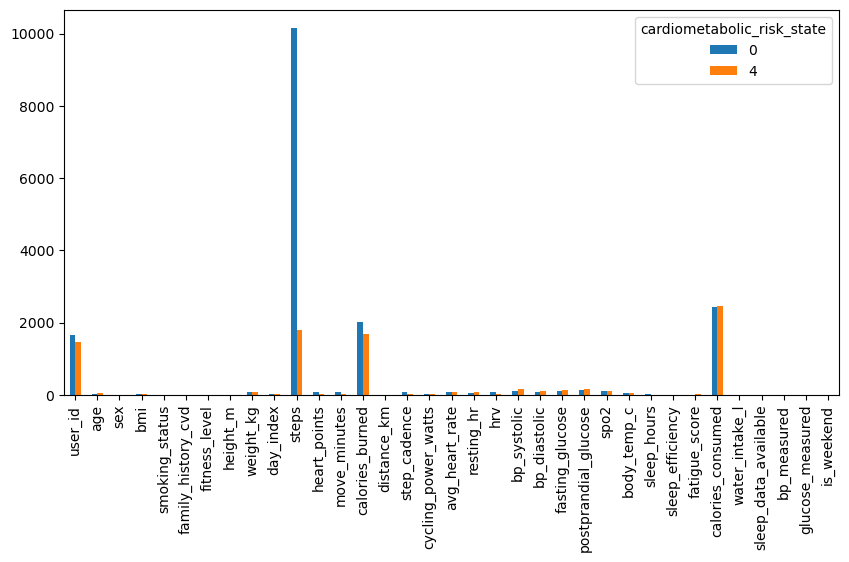

In [50]:
comparison.loc[[0, 4]].T.plot(kind="bar", figsize=(10,5))

In [ ]:
# differenz berechnen
diff = comparison.loc[4] - comparison.loc[0]
print(diff.sort_values())

steps                  -8361.271389
calories_burned         -336.728057
user_id                 -183.706863
hrv                      -61.852826
move_minutes             -54.209712
heart_points             -53.610400
step_cadence             -53.015844
cycling_power_watts       -9.080926
distance_km               -6.270986
sleep_hours               -3.432970
fitness_level             -1.161745
spo2                      -0.704133
sleep_efficiency          -0.287004
water_intake_l            -0.032728
glucose_measured          -0.016303
bp_measured               -0.010424
height_m                   0.005548
is_weekend                 0.006367
sleep_data_available       0.011331
sex                        0.027800
smoking_status             0.182909
family_history_cvd         0.240166
day_index                  0.374531
body_temp_c                0.609419
bmi                        3.166572
fatigue_score              9.091475
weight_kg                  9.391353
age                       15

#### 6. Aktivitätsanalyse
- Welche Aktivität verbrennt am meisten Kalorien?
- Durchschnittliche Dauer je Aktivität

#### 7. Zielerreichung 🎯
- Definiere Ziel: z. B. 10.000 Schritte/Tag
- Wie oft erreichst du es?

KPI: Goal Achievement Rate (%)

#### 8. Beste Tageszeit für Aktivität
- Wann bist du am aktivsten?
  - Morgen / Nachmittag / Abend

#### 9. Ausreißer finden
- Tage mit:
  - extrem wenig Bewegung
  - extrem hoher Aktivität

Interpretation: Krankheit? Workout? Fehler?

#### 10. Nutzerverhalten segmentieren

Teile Tage ein in:

- Low Activity
- Medium
- High Activity

Frage: „Wie oft bin ich in welchem Zustand?“

#### 11. Habit-Analyse
- Wie viele Tage in Folge bist du aktiv?
- Gibt es „Drop-offs“?

Insight: „Wo verliere ich meine Routine?“ 

#### 12.Engagement-Score bauen

Erstelle eine Metrik wie: Score = Schritte + Kalorien * Gewichtung

Ziel:
- Tage vergleichen
- Fortschritt messen

#### 13. Storytelling

Beantworte: „Was sind die 3 wichtigsten Erkenntnisse aus meinen Fitness-Daten?“

#### 14. Dashboard bauen

Zeige:
- KPI: Ø Schritte
- Trend: Aktivität über Zeit
- Breakdown: Aktivitätstypen
- Zielerreichung